# Demo Analysis

This notebook demonstrates the `journal_alignment` package. The implementation stays in `src/journal_alignment/`.

## 1. Setup

Run this notebook from the repository root (`nlp/`) so the default project paths resolve correctly.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from journal_alignment import ProjectConfig
from journal_alignment.pipeline import AlignmentPipeline

## 2. Load configuration

The default configuration expects the raw PubMed CSV and Aims & Scope text file under `data/raw/`.

In [2]:
config = ProjectConfig()

config_summary = pd.DataFrame(
    {
        "setting": [
            "articles_path",
            "aims_scope_path",
            "results_dir",
            "figures_dir",
            "tables_dir",
            "model_name",
            "top_n",
        ],
        "value": [
            config.articles_path,
            config.aims_scope_path,
            config.results_dir,
            config.figures_dir,
            config.tables_dir,
            config.model_name,
            config.top_n,
        ],
    }
)
display(config_summary)

,setting,value
0,articles_path,..\data\raw\articles_pubmed.csv
1,aims_scope_path,..\data\raw\aims_scope.txt
2,results_dir,..\data\results
3,figures_dir,..\reports\figures
4,tables_dir,..\reports\tables
5,model_name,sentence-transformers/all-MiniLM-L6-v2
6,top_n,10


## 3. Run pipeline

The pipeline loads the inputs, computes alignment scores, saves CSV outputs, and creates plots.

In [3]:
pipeline = AlignmentPipeline(config)
results = pipeline.run()

list(results.keys())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

['alignment_scores',
 'summary_statistics',
 'yearly_alignment',
 'top_aligned_articles',
 'least_aligned_articles',
 'outlier_articles']

## 4. Article-level scores

The main output contains one row per article with semantic and TF-IDF alignment scores.

In [4]:
article_scores = results["alignment_scores"]
article_columns = [
    "pmid",
    "title",
    "year",
    "alignment_score",
    "tfidf_alignment_score",
    "is_outlier",
]
display(article_scores[[column for column in article_columns if column in article_scores.columns]].head())

,pmid,title,year,alignment_score,tfidf_alignment_score,is_outlier
0,41695741,"Orthopedic trinity: Arthroscopy, sports medici...",2026,0.669819,0.171738,True
1,41695740,Laminectomy alone vs laminectomy with posterio...,2026,0.332878,0.098022,False
2,41695739,Early dislocation in primary total hip arthrop...,2026,0.472033,0.180393,False
3,41695738,Phosphatidylinositol-3-kinase/protein kinase B...,2026,0.309041,0.068595,False
4,41695737,Impact of preoperative frailty on complication...,2026,0.385670,0.063505,False


## 5. Yearly scores

The yearly table aggregates article-level alignment scores by publication year.

In [5]:
display(results["yearly_alignment"])

,year,count,mean,median,std,min,max
0,2016,111,0.357216,0.370834,0.081719,0.087923,0.537824
1,2017,125,0.364335,0.366542,0.081918,0.073298,0.559148
2,2018,40,0.379141,0.381060,0.072824,0.237864,0.526003
3,2019,48,0.385472,0.399405,0.068859,0.233010,0.517107
4,2020,64,0.389127,0.390607,0.083338,0.203573,0.551178
5,2021,98,0.388673,0.390532,0.095156,0.111386,0.712187
6,2022,102,0.394556,0.390514,0.081091,0.159108,0.600366
7,2023,90,0.381093,0.379670,0.078587,0.168872,0.658364
8,2024,140,0.381794,0.385711,0.076139,0.144970,0.565285
9,2025,163,0.381676,0.388554,0.080270,0.050142,0.574790


## 6. Top and bottom articles

These tables show the highest and lowest scoring articles according to the embedding alignment score.

In [6]:
ranking_columns = ["pmid", "title", "year", "alignment_score", "tfidf_alignment_score"]

top_articles = results["top_aligned_articles"]
bottom_articles = results["least_aligned_articles"]

display(top_articles[[column for column in ranking_columns if column in top_articles.columns]])
display(bottom_articles[[column for column in ranking_columns if column in bottom_articles.columns]])

,pmid,title,year,alignment_score,tfidf_alignment_score
0,33614424,New Year's greeting and overview of World Jour...,2021,0.712187,0.230183
1,41695741,"Orthopedic trinity: Arthroscopy, sports medici...",2026,0.669819,0.171738
2,37662667,Scientific publications on orthopedic surgery ...,2023,0.658364,0.151271
3,33816143,Bibliometric analysis of research on the effec...,2021,0.634733,0.122559
4,36312521,Baishideng's Reference Citation Analysis datab...,2022,0.600366,0.255232
5,41480508,Advancing global orthopedic research through c...,2025,0.574790,0.166639
6,39473516,Evidence-based orthobiologic practice: Current...,2024,0.565285,0.129169
7,39850040,Limited evidence to support demineralized bone...,2025,0.564111,0.127945
8,29094011,Scaffolds based therapy for osteochondral lesi...,2017,0.559148,0.116554
9,41608494,Factors associated with aseptic loosening afte...,2026,0.555577,0.106912


,pmid,title,year,alignment_score,tfidf_alignment_score
0,39850033,Role of neurogenic inflammation in interverteb...,2025,0.050142,0.060431
1,29312846,Role of fast-setting cements in arthroplasty: ...,2017,0.073298,0.054339
2,28032039,Glomus tumors of the fingers: Expression of va...,2016,0.087923,0.071253
3,34189074,Slacklining: A narrative review on the origins...,2021,0.111386,0.066557
4,27622153,Slacklining and stroke: A rehabilitation case ...,2016,0.137132,0.072791
5,39600859,Metagenomic next-generation sequencing may ass...,2024,0.144970,0.074388
6,28660138,Emergent reintubation following elective cervi...,2017,0.156543,0.078031
7,36159620,Social media growth of orthopaedic surgery res...,2022,0.159108,0.087019
8,34754832,Clinical outcome after surgery on schwannomas ...,2021,0.161761,0.132046
9,36439370,Genetics of congenital anomalies of the hand.,2022,0.167444,0.110935


## 7. Saved visualizations

The pipeline saves standard plots under `reports/figures/`.

..\reports\figures\alignment_histogram.png


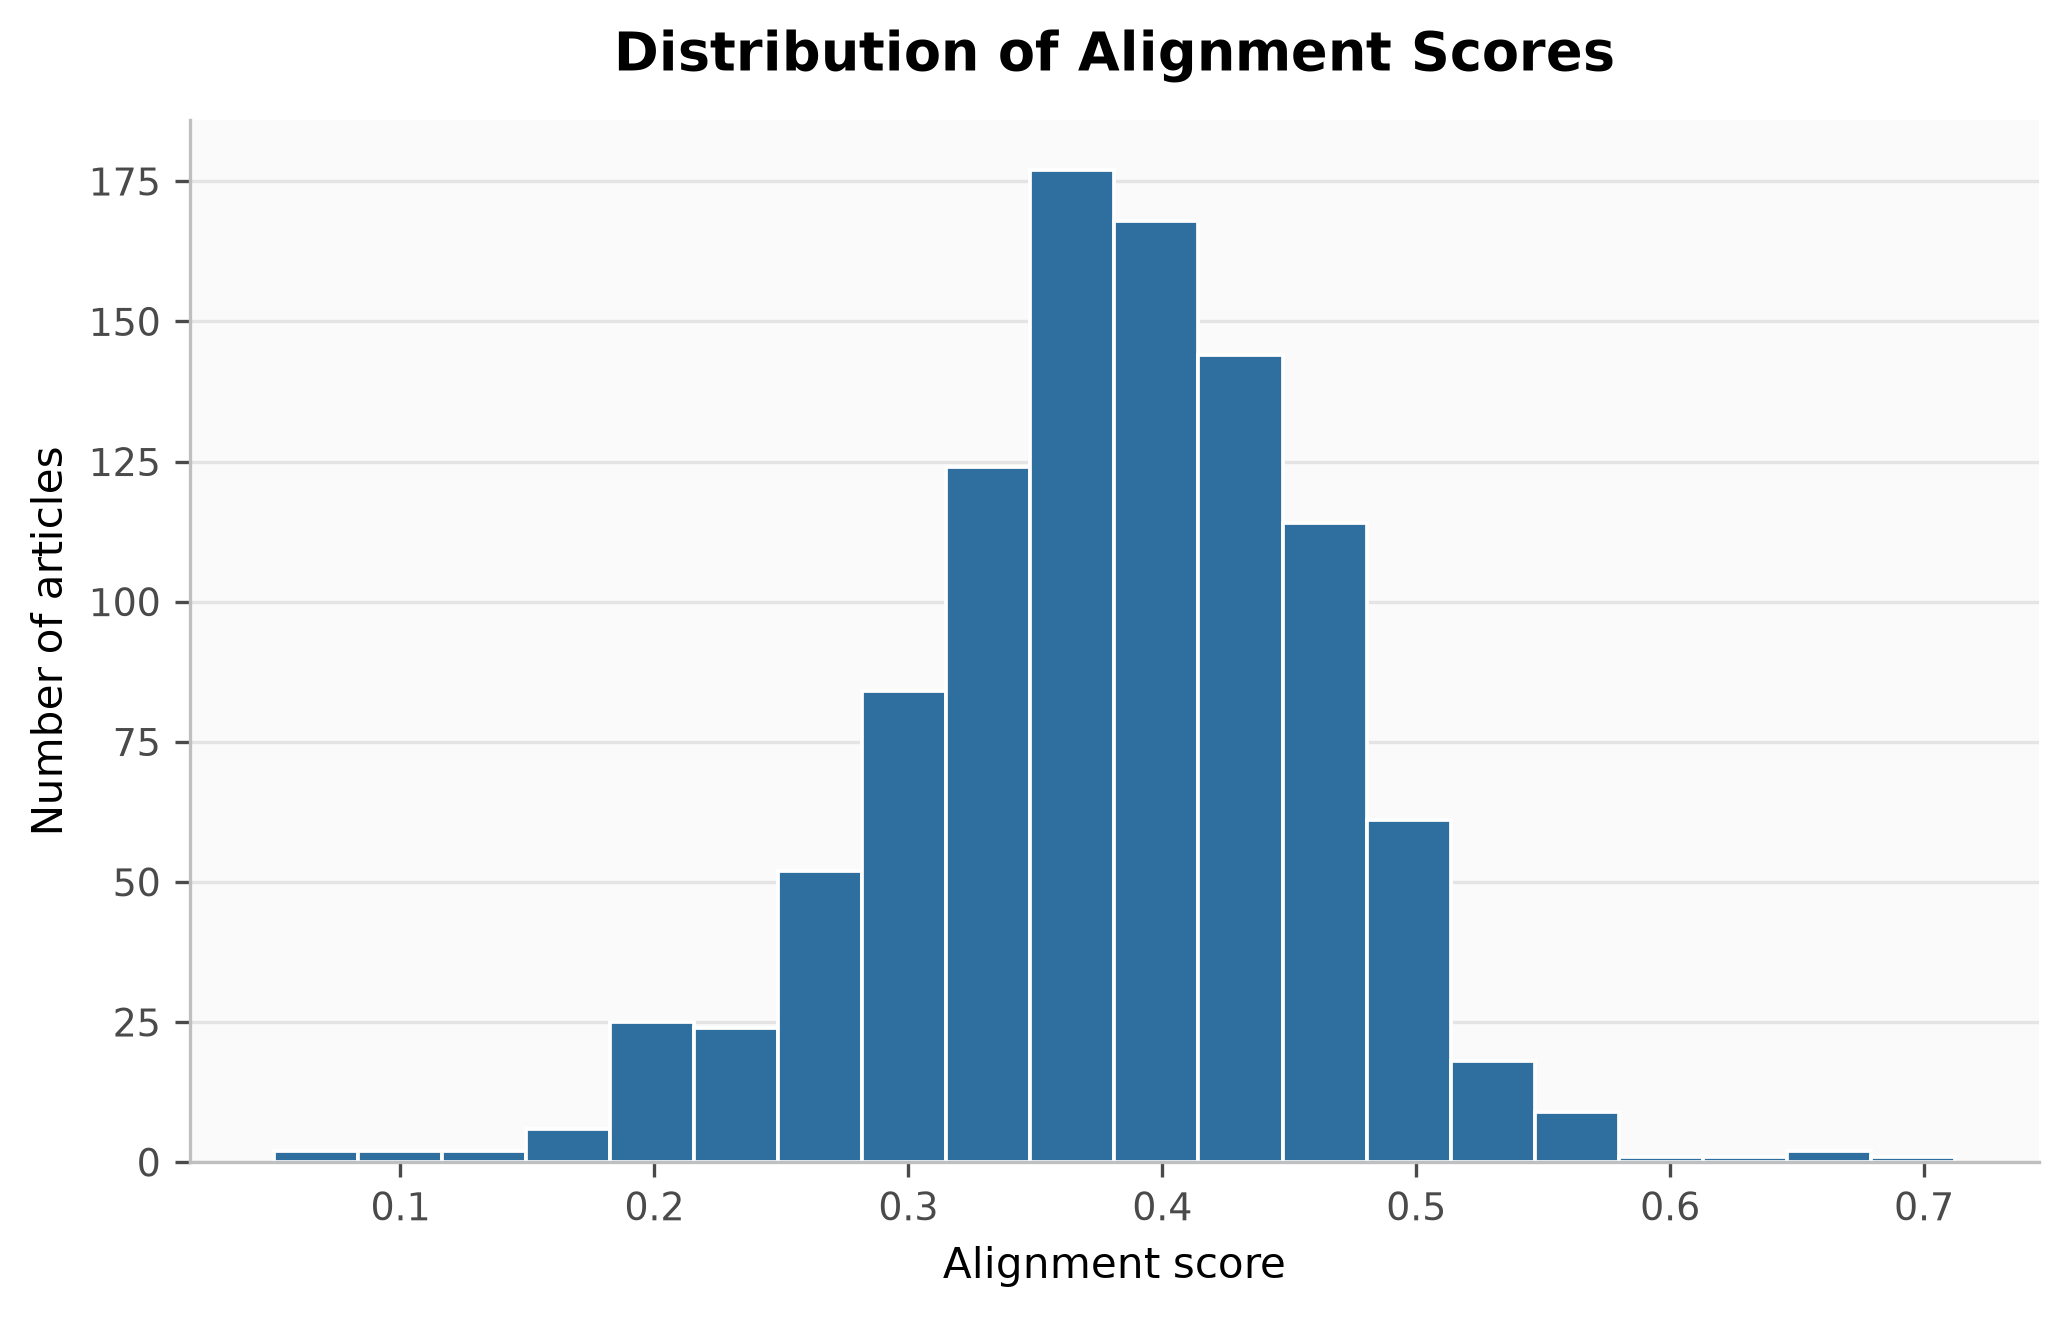

..\reports\figures\alignment_boxplot.png


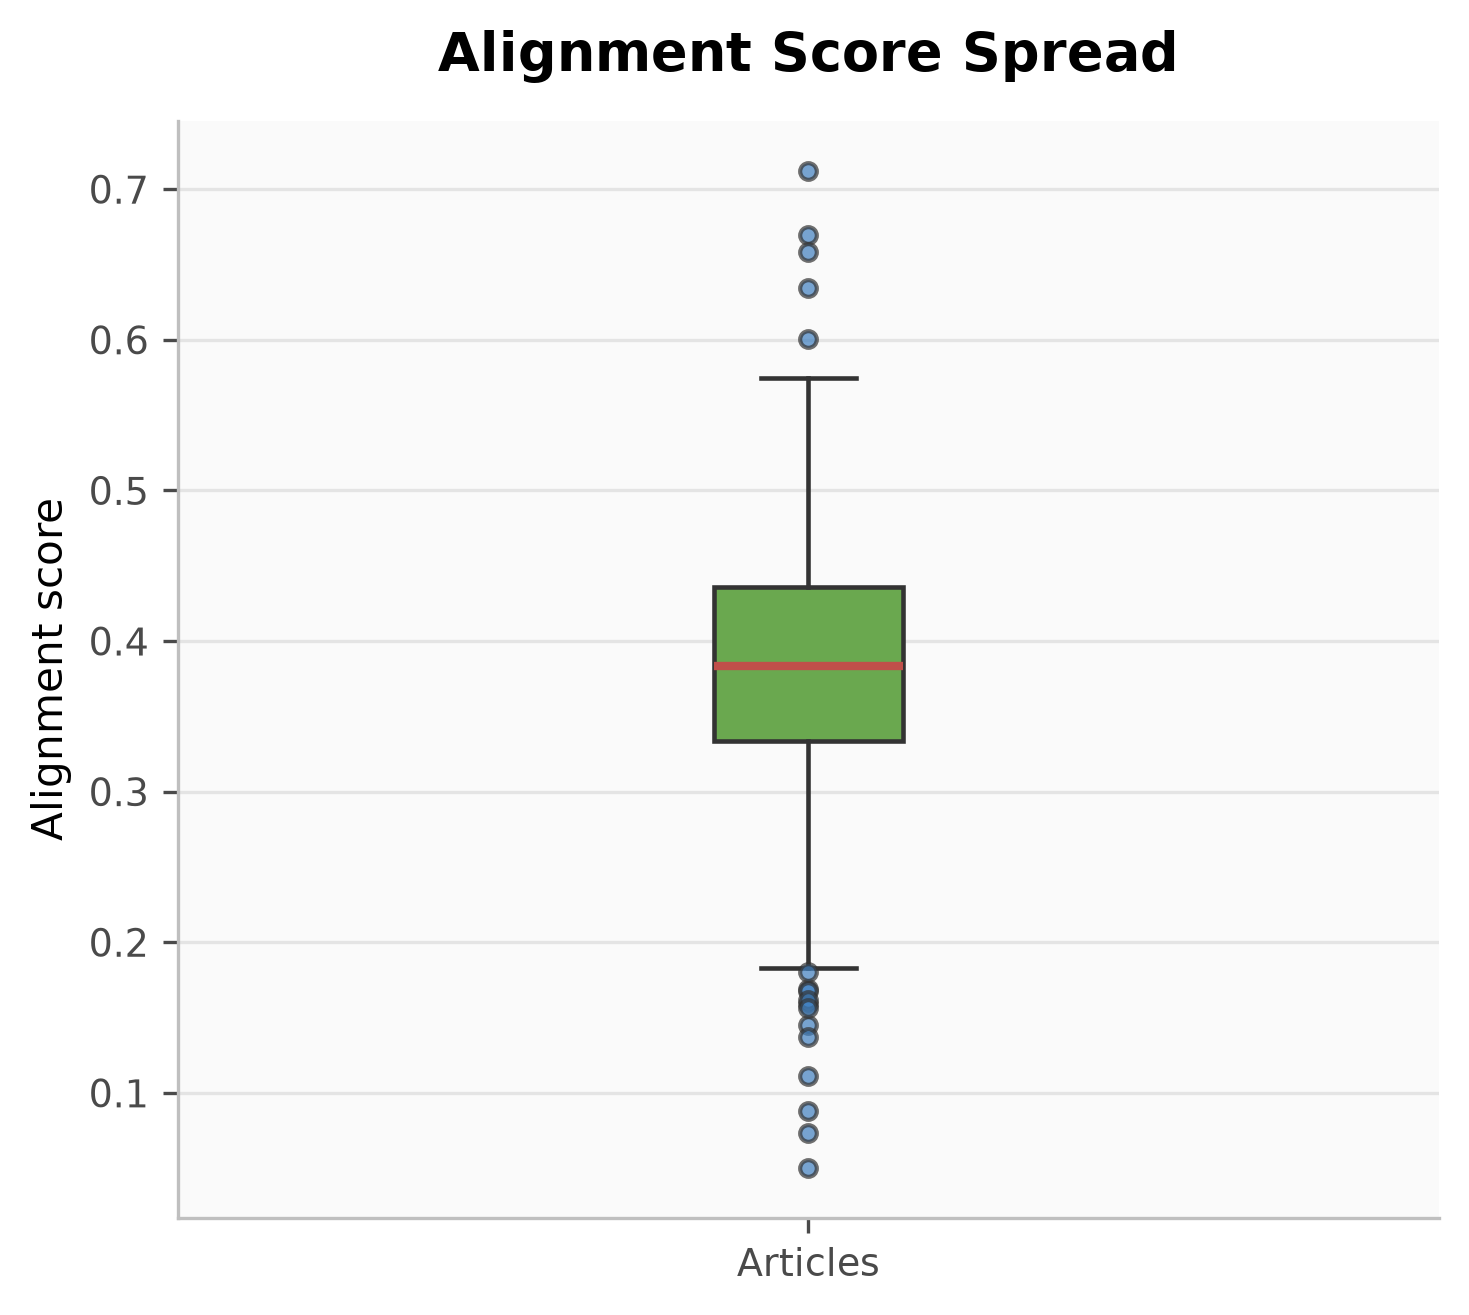

..\reports\figures\alignment_by_year.png


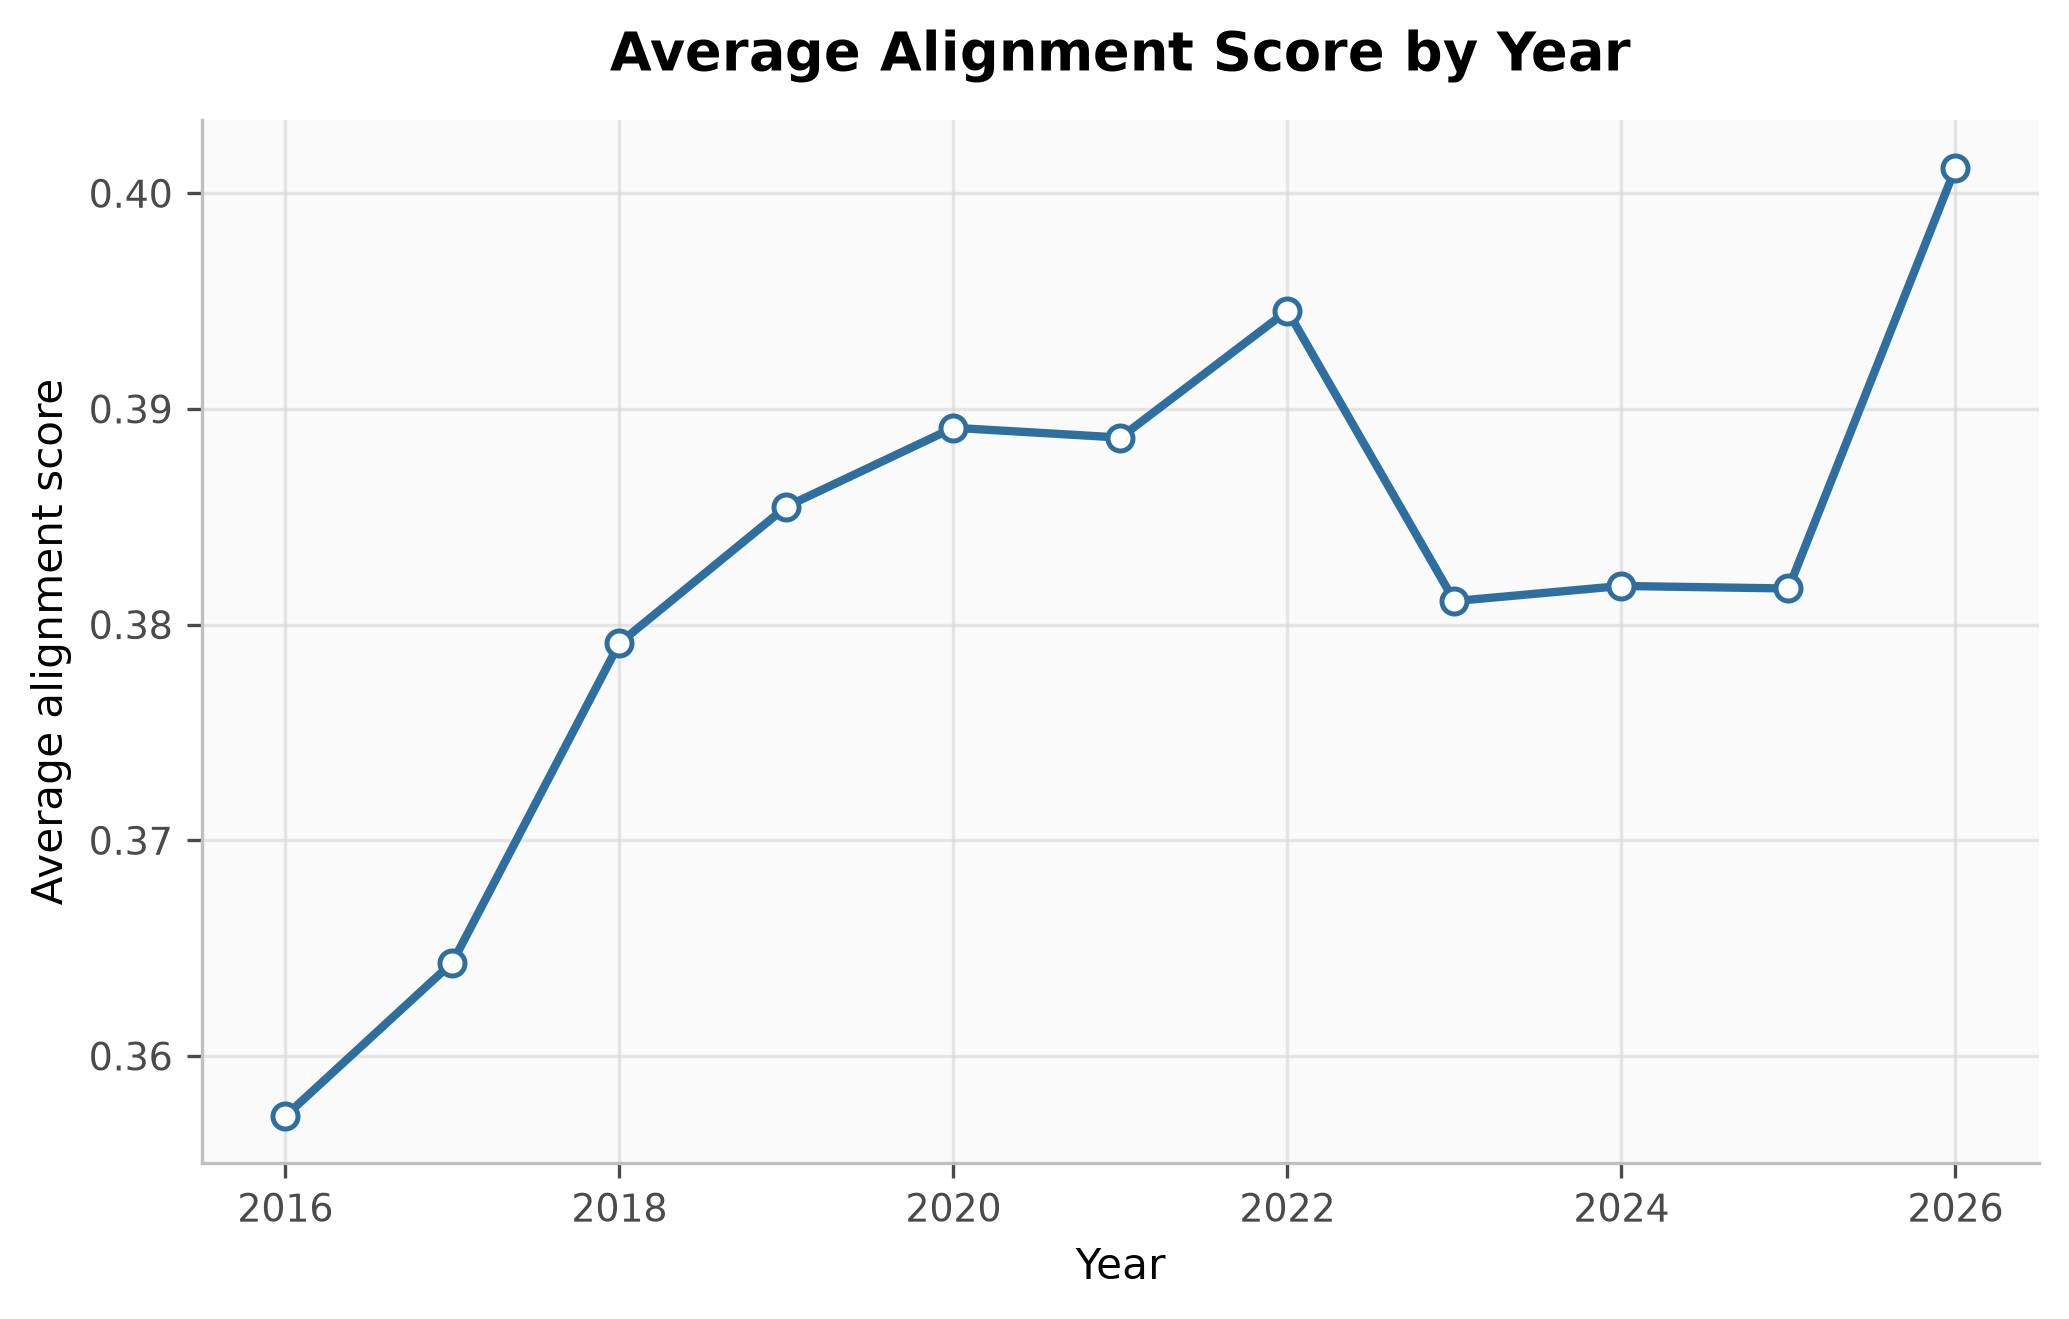

..\reports\figures\article_scores_by_year.png


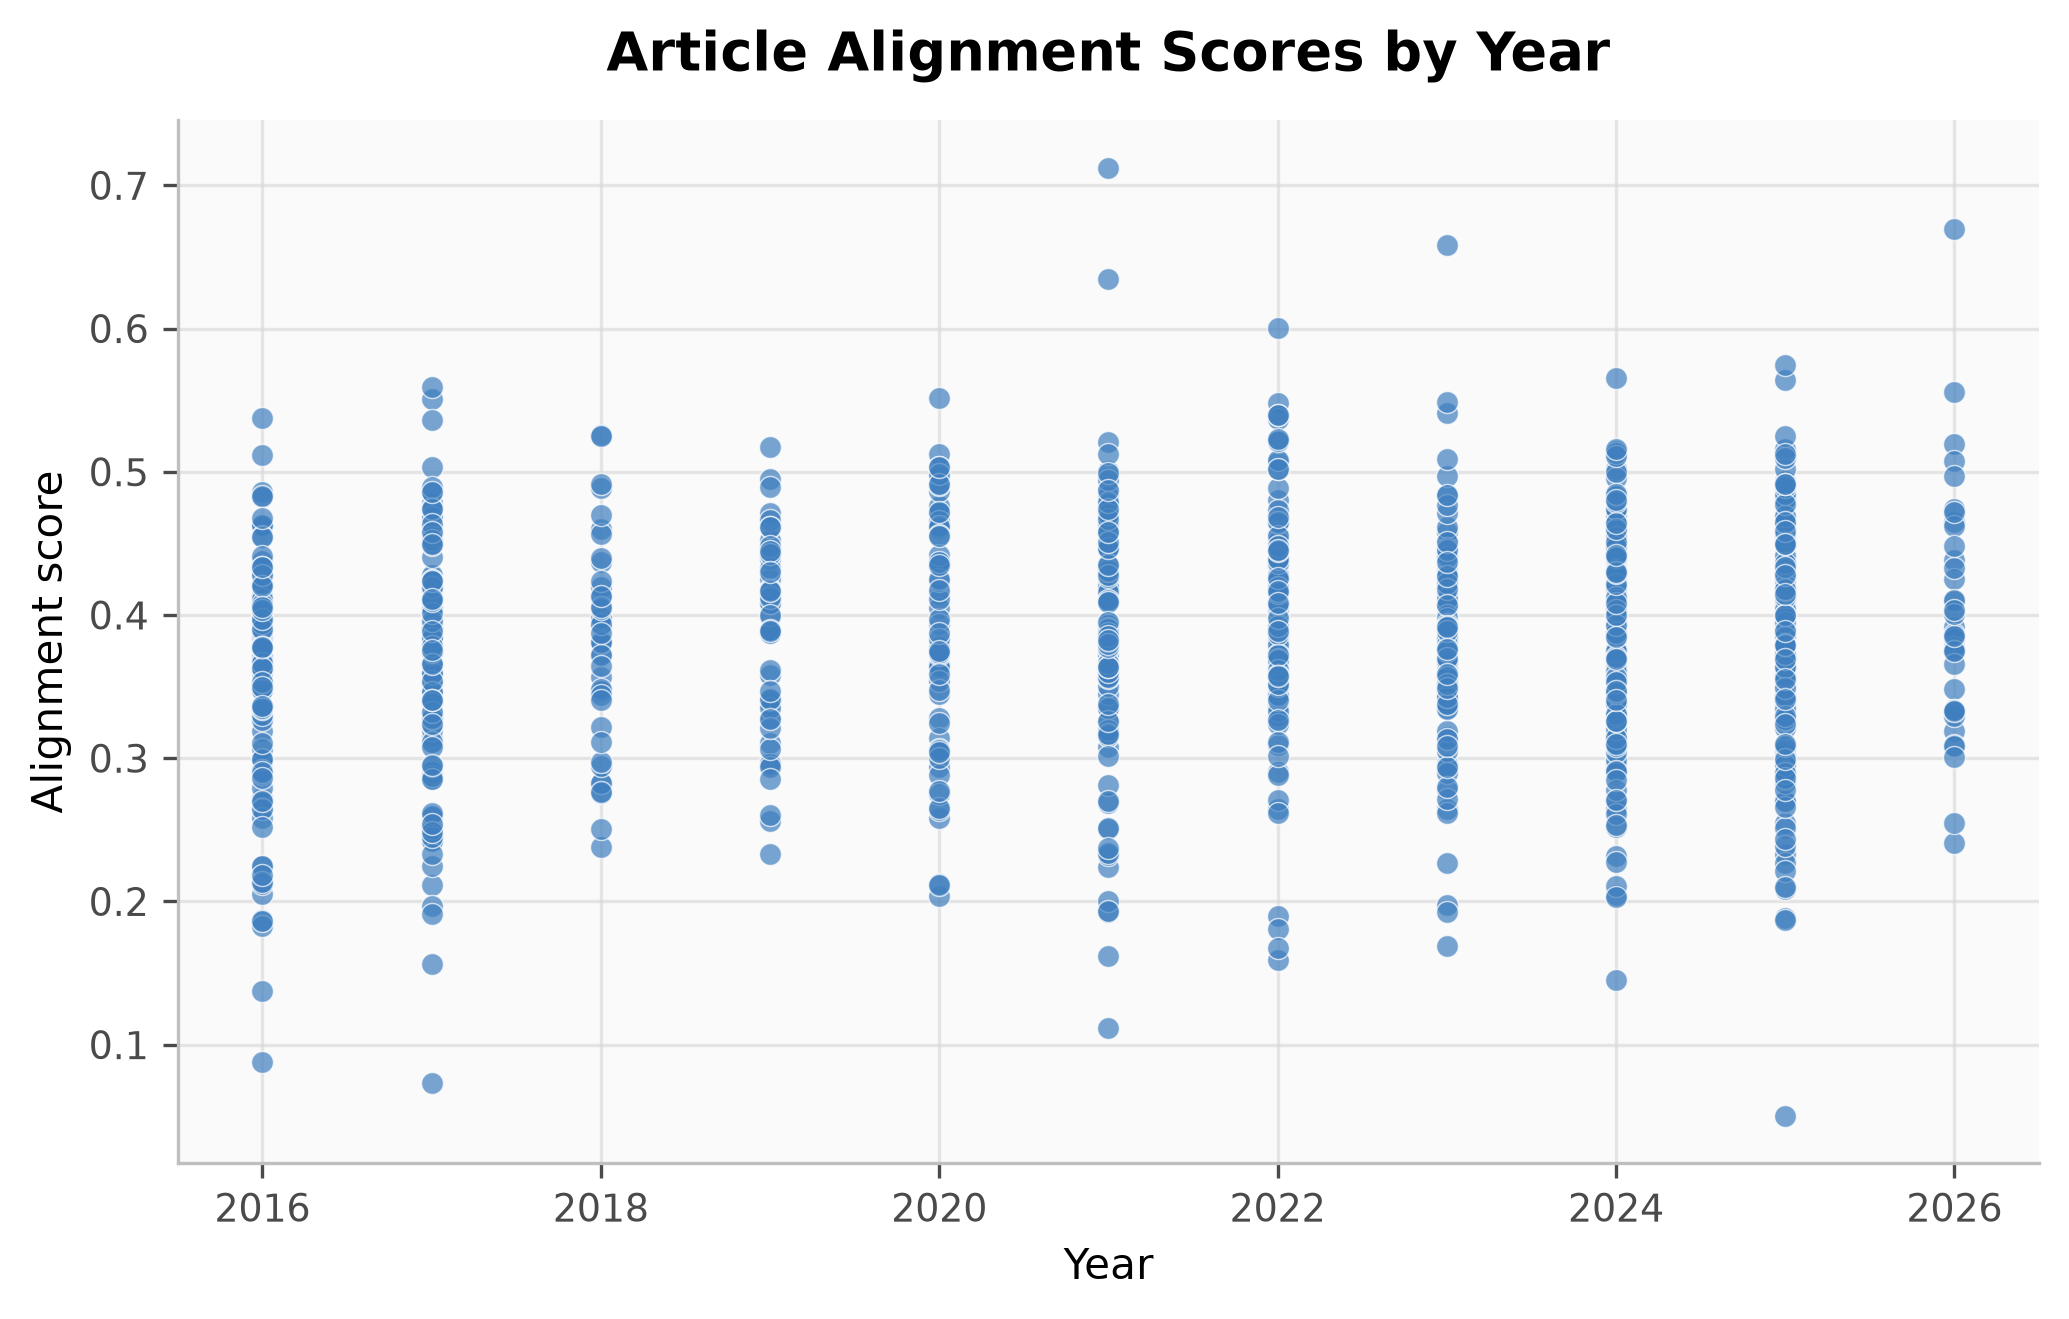

In [7]:
figure_paths = [
    config.figures_dir / "alignment_histogram.png",
    config.figures_dir / "alignment_boxplot.png",
    config.figures_dir / "alignment_by_year.png",
    config.figures_dir / "article_scores_by_year.png",
]

for figure_path in figure_paths:
    print(figure_path)
    if figure_path.exists():
        display(Image(filename=str(figure_path)))
    else:
        print("Plot not found. Run the pipeline cell first.")